In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from flonacomldft.utils.io_utils import (
    load_pickle_file,
    get_path, 
    get_project_path
)

from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.diagnostics import R_hat

from flonacomldft.utils.plots import (
    set_plot_sequential_data,
    plot_energy_surface,
    plot_energy_histogram,
)

from numpy.lib.stride_tricks import sliding_window_view

import matplotlib.pylab as pylab

size=16
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [3]:
# paths
DFT_DATA_PATH = get_path() + '/andersen/'
DFT_SIMS_PATH = get_project_path()

In [4]:
# simulation files
mcmc_paths = ['4-multimodal/results_multimodal_sampling_mixture_30367820/mixture_mcmc_dic_30367820.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_30489420/mixture_mcmc_dic_30489420.pkl']

cvs_paths = ['4-multimodal/results_multimodal_sampling_mixture_30367820/cvs_mixture_30367820.pkl',
        '5-multimodal-mlp/results_multimodal_sampling_mixture_30489420/cvs_mixture_30489420.pkl']

# load mcmc results
keys = ['ab-flowMM w.o NP', 'ab-flowMM']
color_keys = dict(zip(keys, ['blue', 'orange', 'red']))
mcmcs = {key: load_pickle_file(mcmc_path, DFT_SIMS_PATH) for mcmc_path, key in zip(mcmc_paths, keys)}
cvs = {key: load_pickle_file(cv_path, DFT_SIMS_PATH) for cv_path, key in zip(cvs_paths, keys)}

# Acceptance ratio

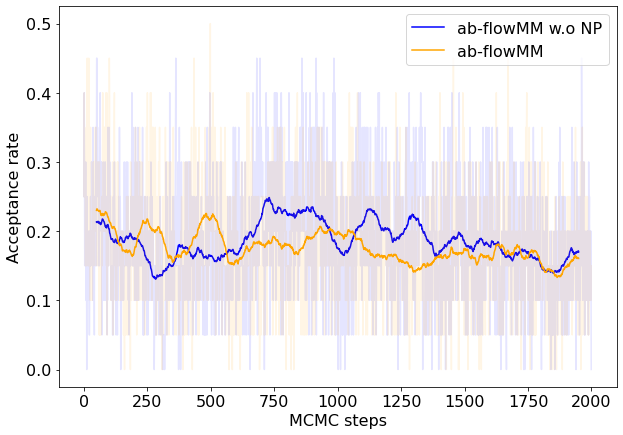

In [5]:
accs = {key: mcmcs[key]['accs'].float().mean(dim=1).detach() for key in mcmcs.keys()}

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in accs.keys():

    set_plot_sequential_data(accs[key], 
                                ax=ax,
                                window_size=100,
                                alpha=0.1, 
                                label=key, 
                                color=color_keys[key])
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Acceptance rate')

ax.legend()

# Collective variables

In [6]:
isomers = {key: mcmcs[key]['isomers'] for key in mcmcs.keys()}

In [7]:
isomer_colors = dict(zip([0, 1], ['cyan', 'salmon']))

In [8]:
cvs_isomers = {key: torch.cat((cvs[key], isomers[key].reshape(2000, 20, 1), 
                               #mcmcs[key]['us'].reshape(2000, 20, 1)
                               ), dim=2) for key in cvs.keys()}

In [9]:
#for i, cv in enumerate(cvs_isomers[keys[1]][:, 4, :]):
#    if cvs_isomers[keys[1]][:, 4, :].max() == cv.max():
#        print(i, cv)

In [10]:
#for i, cv in enumerate(cvs_isomers[keys[1]][:, 7, :]):
#    if cvs_isomers[keys[1]][:, 7, :].max() == cv.max():
#        print(i, cv)

In [11]:
#for i in range(20):
#    print(i, cvs_isomers[keys[1]][:, i, 0].max())

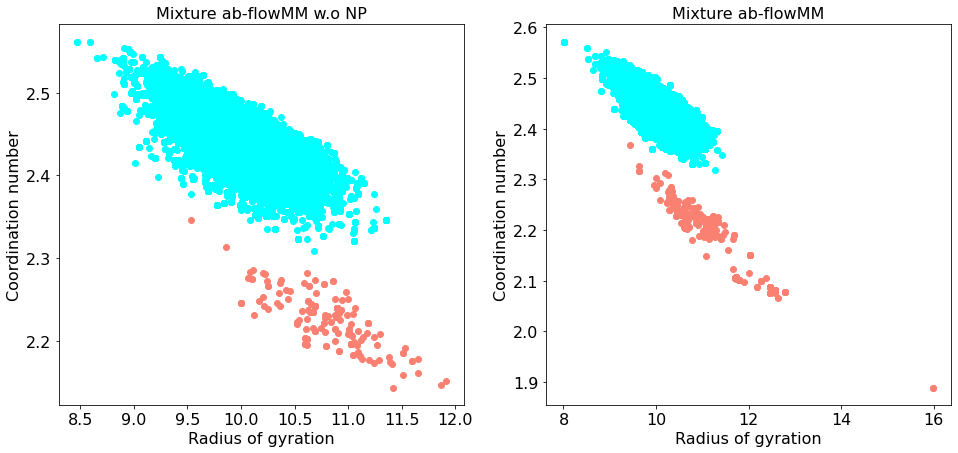

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(16, 7))

axs = axs.ravel()

for ax, key in zip(axs, cvs.keys()):
    for isomer in [0, 1]:
        mask = cvs_isomers[key][:, :, 2] == isomer

        cvs_flatten = cvs_isomers[key][mask].reshape(-1, 3)
        ax.scatter(cvs_flatten[:, 0], cvs_flatten[:, 1], 
                   label='Isomer {:d}'.format(isomer), color=isomer_colors[isomer])
    
    ax.set_title('Mixture {:s}'.format(key))
    ax.set_xlabel('Radius of gyration')
    ax.set_ylabel('Coordination number')

    #ax.set_xlim(8.5, 12)
    #ax.set_ylim(2.0, 2.6)

# Jumps along chains

In [13]:
def plot_jums_along_chains(ax, isomers, size=6):

    isomers = isomers.T

    for i in range(isomers.shape[0]):

        jumps, counts = isomers[i].unique_consecutive(return_counts=True)

        colors_array = []
        
        for j in range(jumps.shape[0]):
            if jumps[j]==0:
                colors_array.append('cyan')
            else:
                colors_array.append('salmon')
        
        ax.plot(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), 'k--', alpha=0.4)
        ax.scatter(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), s=counts*size, color=colors_array)
    
    ax.set_xlabel('Chains')
    ax.set_ylabel('Jumps')

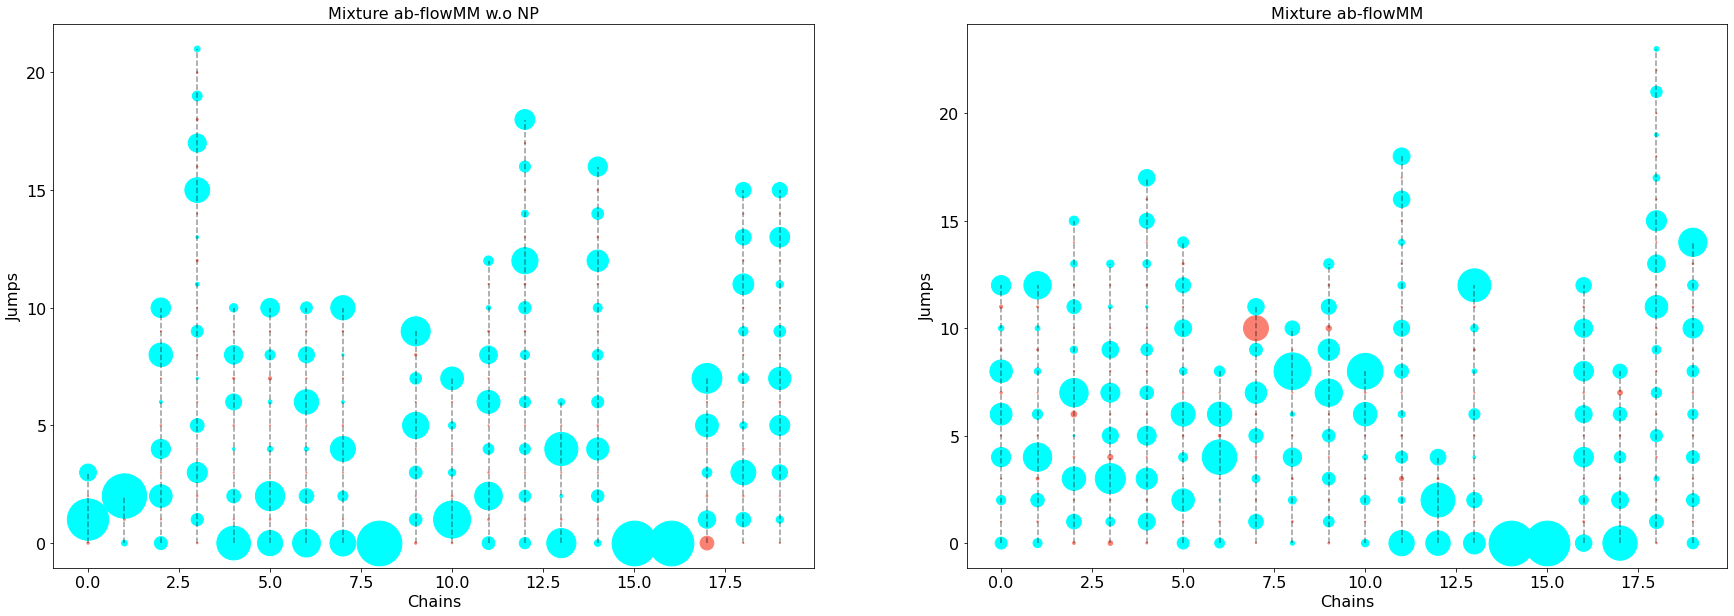

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(30, 10))

axs = axs.ravel()

for ax, key in zip(axs, isomers.keys()):
    plot_jums_along_chains(ax, isomers[key], size=1)

    ax.set_title('Mixture {:s}'.format(key))

In [15]:
def plot_jumps_along_steps(ax, isomers):

    ax.plot(isomers.detach().numpy(), '.-')
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Isomer')

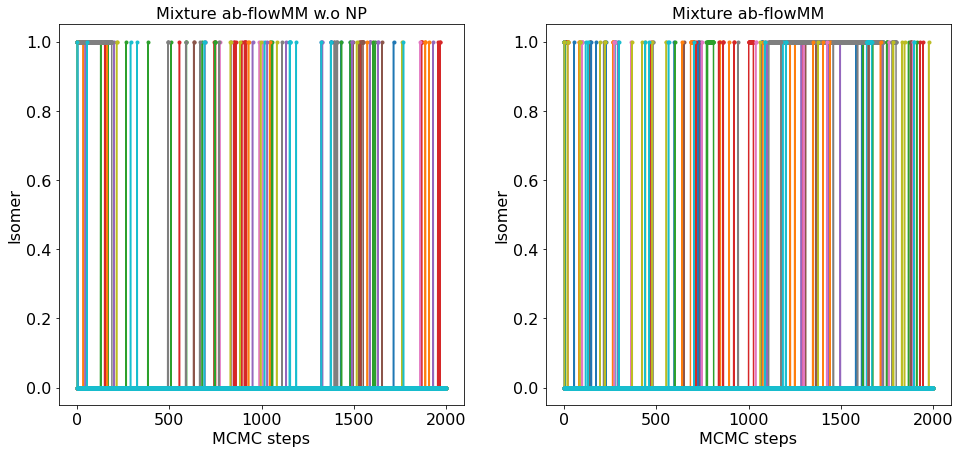

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(16, 7))

axs = axs.ravel()

for ax, key in zip(axs, isomers.keys()):
    plot_jumps_along_steps(ax, isomers[key])

    ax.set_title('Mixture {:s}'.format(key))

# Rhat

In [17]:
rhat = {key: R_hat(torch.cat((cvs[key].reshape(2000, 20, 2), mcmcs[key]['us'].reshape(2000, 20, 1)), dim=2).detach().numpy().transpose(1, 0, 2), 
                    labels=['Coordination number', 'Radius of gyration', 'Energy']) for key in keys if key != 'MD'}

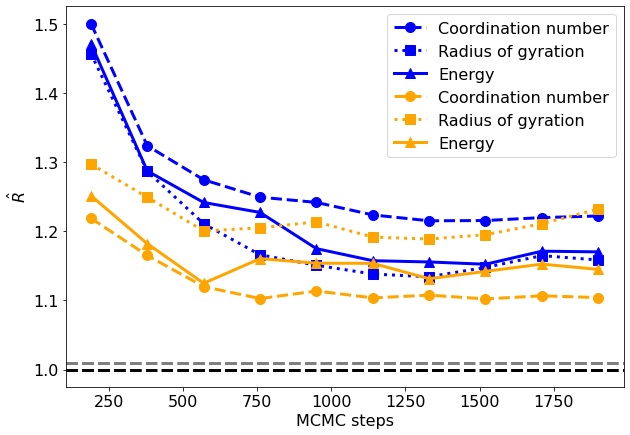

In [18]:
fig, axs = plt.subplots(1, 1, figsize=(10, 7))

markers = ['o', 's', '^']
linestyles = ['dashed', 'dotted', '-']
for key in rhat.keys():
    for i in range(rhat[key][0].shape[-1]):
        axs.plot(rhat[key][1], 
                rhat[key][0][:, i], 
                linestyle=linestyles[i], 
                marker=markers[i],
                markersize=10,
                linewidth=3,
                color=color_keys[key], 
                label=rhat[key][2][i],
                )

        axs.axhline(1, c='k', ls='--', linewidth=3)
        axs.axhline(1.01, c='grey', ls='--', linewidth=3)

        axs.set_xlabel('MCMC steps')
        axs.set_ylabel(r'$\hat{R}$')

        axs.legend()

# Energies

Text(0.5, 1.0, 'Energy histogram')

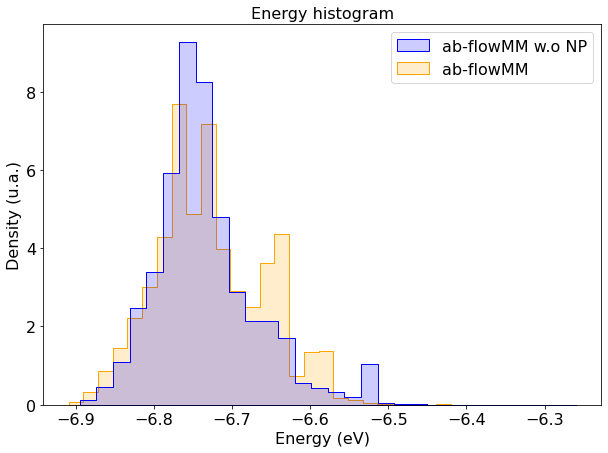

In [19]:
us = {key: mcmcs[key]['us'].flatten().detach() for key in mcmcs.keys()}

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

plot_energy_histogram(us, 
                      ax=axs, 
                      bins=30, 
                      alpha=0.2, 
                      element='step', 
                      common_bins=False, 
                      common_norm=False,
                      palette=color_keys,)
axs.set_title(f'Energy histogram')

# Populations

(0.0, 0.07)

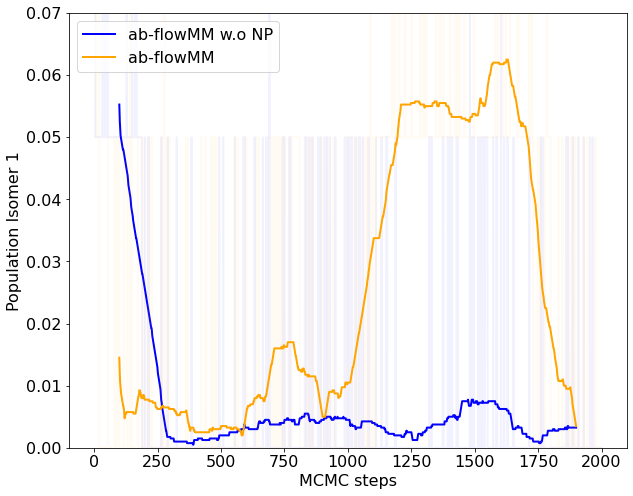

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
n=0
for key in keys:
    set_plot_sequential_data(isomers[key][n:, :].mean(dim=1).detach(), 
        avg=True, 
        window_size=200, 
        ax=ax,
        linewidth=2,
        label=key, color=color_keys[key], alpha=0.05)

    #ax.axhline(isomers[key][n:, :].mean().detach(), 0, 2000, 
    #            linestyle='--', color='red',
    #            label='Mean {:.1e}'.format(isomers[key][n:, :].mean().detach()) )

ax.set_xlabel('MCMC steps')
ax.set_ylabel('Population Isomer 1')
#ax.set_yscale('log')
ax.legend()

ax.set_ylim(0, 0.07)

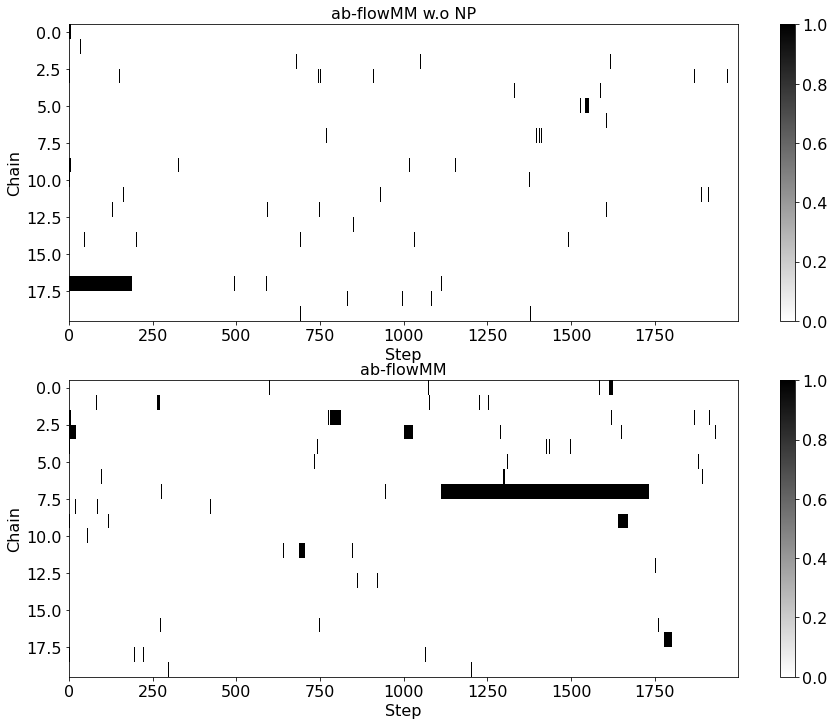

In [27]:
fig, axs = plt.subplots(2, 1, figsize=(15, 12))
for key, ax in zip(keys, axs):
    ax.imshow(isomers[key].numpy().T, aspect='auto', cmap='gray_r', interpolation='none')
    ax.set_xlabel('Step')
    ax.set_ylabel('Chain')
    ax.set_title(key)
    fig.colorbar(ax.imshow(isomers[key].numpy().T, aspect='auto', cmap='gray_r', interpolation='none'), ax=ax)